In [1]:
from resources.imports import *

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, Autoencoder

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)
DAT.train_in.shape, DAT.val_in.shape, DAT.test_in.shape

((353, 900), (63, 900), (137, 900))

# Principal Component Analysis (PCA)

In [5]:
X_data = np.concatenate((DAT.train_in, DAT.val_in, DAT.test_in))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

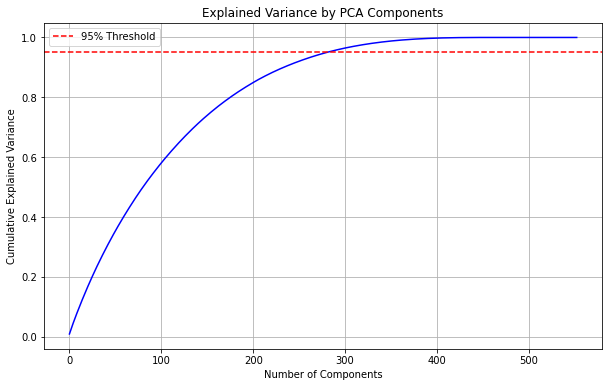

Number of components to capture 65% variance: 121
Number of components to capture 80% variance: 176
Number of components to capture 90% variance: 234
Number of components to capture 95% variance: 281
Number of components to capture 100% variance: 489


In [6]:
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'b-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()

n_components_65 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.65)[0][0] + 1
n_components_80 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.8)[0][0] + 1
n_components_90 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.9)[0][0] + 1
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
n_components_100 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 1)[0][0] + 1
print(f"Number of components to capture 65% variance: {n_components_65}")
print(f"Number of components to capture 80% variance: {n_components_80}")
print(f"Number of components to capture 90% variance: {n_components_90}")
print(f"Number of components to capture 95% variance: {n_components_95}")
print(f"Number of components to capture 100% variance: {n_components_100}")

In [7]:
final_pca = PCA(n_components=n_components_100)
X_reduced = final_pca.fit_transform(X_scaled)

print(f"Original data shape: {X_data.shape}")
print(f"Reduced data shape: {X_reduced.shape}")

Original data shape: (553, 900)
Reduced data shape: (553, 489)


In [8]:
X_recon = final_pca.inverse_transform(X_reduced)
X_recon = scaler.inverse_transform(X_recon)

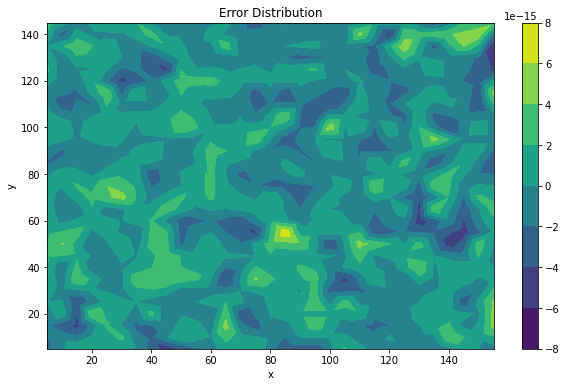

2.1923534793043095e-15

In [9]:
indx = 256
xy = 0

plt_outputs = X_recon[indx].reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = DAT.train_in[indx].reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(DAT.train_in1, plt_outputs, truth=truth)

np.sqrt(np.mean((plt_outputs - truth) ** 2))

# Autoencoder

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_size = DAT.train_in.shape[-1]
h_size = []
latent_size = 100

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

Using device: cpu


In [11]:
trainDS = Dataset_(DAT.train_in, DAT.train_in)
testDS = Dataset_(DAT.test_in, DAT.test_in)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
ENC = MODEL(
    typ="MLP",
    model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=EarlyStopping(patience=100, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(ENC.model, input_size=(BATCH_SIZE, in_size))

c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 900]                  --
├─MLP: 1-1                               [1, 100]                  --
│    └─Linear: 2-1                       [1, 100]                  90,100
├─MLP: 1-2                               [1, 900]                  --
│    └─Linear: 2-2                       [1, 900]                  90,900
Total params: 181,000
Trainable params: 181,000
Non-trainable params: 0
Total mult-adds (M): 0.18
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.72
Estimated Total Size (MB): 0.74

In [14]:
# ENC.train(n_epochs=500, verbose=50, plot=True)

Best prediction: 326, Worst prediction: 188


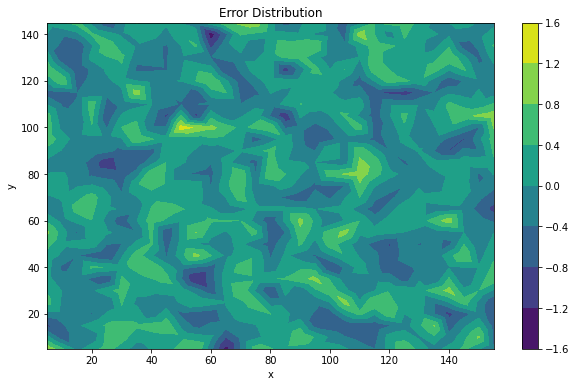

0.4863404

In [15]:
ENC.predict(stand=False, plot=False, test_dataloader=ENC.train_dataloader)

indx = 51      # ADAPT CLASS (model or data) TO AUTOENCODER STRUCTURES
xy = 0

plt_outputs = ENC.test_outputs[indx].reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = ENC.truth[indx].reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(ENC.data.train_in1, plt_outputs, truth=truth, typ="contour")

np.sqrt(np.mean(np.square(plt_outputs - truth)))

In [16]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden_dim = trial.suggest_int('hidden_dim', 8, 64, log=True)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [1, 2, 8, 16])

    h_size = [hidden_dim] * n_layers

    enc_instance = MODEL(
        typ="MLP",
        model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device),
        lossf=nn.MSELoss(),
        opt=("adam", 0),
        batch=batch_size,
        lr=lr,
        data=DAT,
        train_dataloader=train_dataloader,
        val_dataloader=None,
        scheduler=("min", 0.7, 10, 1e-4, True),
        earlyStop=EarlyStopping(patience=10, verbose=False),
        w_init=weights_init,
        optTrial=trial  # Pass the trial object here
    )

    enc_instance.train(n_epochs=50, verbose=50)
    return enc_instance.best_loss


pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="minimize", pruner=pruner)
study.optimize(objective, n_trials=50)

print("\n" + "="*40)
print("Study statistics: ")
print(f"  Number of finished trials: {len(study.trials)}")

print("\nBest trial:")
best_trial = study.best_trial
print(f"  Value (min validation loss): {best_trial.value:.4f}")

print("\n  Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-06-17 19:17:55,995] A new study created in memory with name: no-name-92505689-3b3f-4b04-8ecf-27bfbe16ff4e


Epoch: 1 - Loss: 0.6467702388763428


[I 2025-06-17 19:18:13,216] Trial 0 finished with value: 0.610954761505127 and parameters: {'n_layers': 1, 'hidden_dim': 15, 'lr': 0.0016047366036747578, 'batch_size': 8}. Best is trial 0 with value: 0.610954761505127.


Epoch: 50 - Loss: 0.5893393754959106
Best Epoch: 49, with loss 0.610954761505127
Epoch: 1 - Loss: 0.6767445206642151


[I 2025-06-17 19:18:30,735] Trial 1 finished with value: 0.647834300994873 and parameters: {'n_layers': 1, 'hidden_dim': 15, 'lr': 0.005006821838338464, 'batch_size': 8}. Best is trial 0 with value: 0.610954761505127.


...

Epoch: 1 - Loss: 0.6777368783950806


[I 2025-06-17 19:21:33,835] Trial 43 pruned. 


Epoch: 1 - Loss: 0.684303343296051


[I 2025-06-17 19:21:34,613] Trial 44 pruned. 
[I 2025-06-17 19:21:35,240] Trial 45 pruned. 
[I 2025-06-17 19:21:35,683] Trial 46 pruned. 
[I 2025-06-17 19:21:36,091] Trial 47 pruned. 
[I 2025-06-17 19:21:36,618] Trial 48 pruned. 
[I 2025-06-17 19:21:37,236] Trial 49 pruned. 



Study statistics: 
  Number of finished trials: 50

Best trial:
  Value (min validation loss): 0.5694

  Best hyperparameters:
    n_layers: 1
    hidden_dim: 33
    lr: 0.002503511534528621
    batch_size: 16
